In [12]:
import time, io, contextlib
import numpy as np
import matplotlib.pyplot as plt

from MyNeuralNetwork import MyNeuralNetwork
from ActivationFunctions import ReLU, Softmax, Linear
from NN_AE import EvolutionaryNNTrainer

SEED = 42

In [13]:
def train_test_split(X, y, test_ratio=0.3, seed=42, stratify=None):
    rng = np.random.default_rng(seed)
    if stratify is not None:
        tr, te = [], []
        for c in np.unique(stratify):
            ci = np.where(stratify == c)[0]; rng.shuffle(ci)
            k = int(round((1 - test_ratio) * len(ci)))
            tr += list(ci[:k]); te += list(ci[k:])
        tr, te = np.array(tr), np.array(te)
        rng.shuffle(tr); rng.shuffle(te)
    else:
        idx = rng.permutation(len(X)); k = int(round((1 - test_ratio) * len(X)))
        tr, te = idx[:k], idx[k:]
    return X[tr], X[te], y[tr], y[te]

class Standardizer:
    def fit(self, X):
        self.mu = X.mean(0); self.sd = X.std(0); self.sd[self.sd == 0] = 1.0; return self
    def transform(self, X): return (X - self.mu) / self.sd
    def fit_transform(self, X): return self.fit(X).transform(X)
    def inverse(self, X): return X * self.sd + self.mu

def one_hot(y, k): return np.eye(k)[y]
def accuracy(yt, yp): return float(np.mean(yt == yp))
def rmse(yt, yp): return float(np.sqrt(np.mean((np.ravel(yt) - np.ravel(yp)) ** 2)))

def backprop_train(net, X, y, **kw):
    """Run MyNeuralNetwork.train silently; return its loss_history."""
    with contextlib.redirect_stdout(io.StringIO()):
        loss_hist, _, _ = net.train(X, y, **kw)
    return loss_hist

def plot_convergence(ea_hist, bp_hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(ea_hist); ax[0].set_title(f"{title} — EA best loss")
    ax[0].set_xlabel("generation"); ax[0].set_ylabel("loss"); ax[0].grid(alpha=.3)
    ax[1].plot(bp_hist); ax[1].set_title(f"{title} — backprop loss")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

def confusion_matrix(yt, yp, k):
    m = np.zeros((k, k), int)
    for a, b in zip(yt, yp): m[a, b] += 1
    return m

In [14]:
def load_iris(path="iris/iris.data"):
    rows = [l.strip().split(",") for l in open(path) if l.strip()]
    classes = sorted({r[-1] for r in rows}); cm = {c: i for i, c in enumerate(classes)}
    X = np.array([[float(v) for v in r[:-1]] for r in rows])
    y = np.array([cm[r[-1]] for r in rows])
    return X, y, classes

def load_auto_mpg(path="auto+mpg/auto-mpg.data"):
    feats, target = [], []
    for line in open(path):
        line = line.strip()
        if not line: continue
        cols = line.split('"')[0].split()      # drop the quoted car-name column
        target.append(float(cols[0]))          # mpg
        feats.append(cols[1:8])                # 7 features
    arr = np.array(feats, dtype=object)
    out = []
    for j in range(arr.shape[1]):
        col = np.array([np.nan if v == '?' else float(v) for v in arr[:, j]])
        col[np.isnan(col)] = np.nanmedian(col)  # impute '?' (horsepower) with median
        out.append(col)
    return np.column_stack(out), np.array(target).reshape(-1, 1)

def load_multimodal(path):
    d = np.genfromtxt(path, delimiter=",", skip_header=1)
    return d[:, 0:1], d[:, 1:2]

EA  : train_acc=0.990 test_acc=0.978 time=2.7s loss=0.021
BP  : train_acc=1.000 test_acc=0.978 time=0.6s


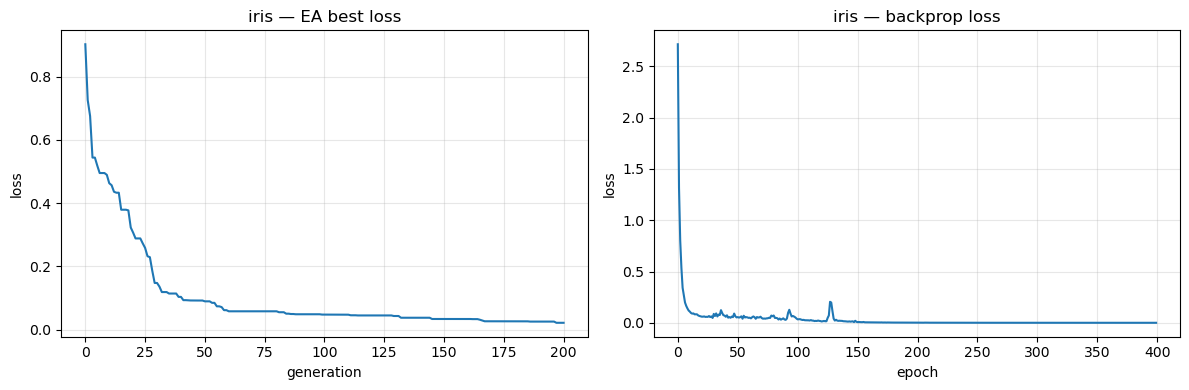

confusion (EA, test):
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


In [15]:
X, y, classes = load_iris()
Xtr, Xte, ytr, yte = train_test_split(X, y, 0.3, seed=SEED, stratify=y)
sc = Standardizer().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
Ytr = one_hot(ytr, 3)

args = [4, [8, 8], 3, ReLU(), Softmax()]

# --- EA ---
net_ea = MyNeuralNetwork(*args, RANDOM_SEED=SEED); net_ea.initialize_weights('he')
t = time.time()
tr = EvolutionaryNNTrainer(net_ea, Xtr_s, Ytr, task="classification",
                           population_size=80, generations=200, mutation_rate=0.1,
                           sigma=0.2, crossover="blx", seed=SEED)
tr.run(); ea_time = time.time() - t
ea_tr, ea_te = accuracy(ytr, tr.predict(Xtr_s)), accuracy(yte, tr.predict(Xte_s))

# --- backprop (same architecture) ---
net_bp = MyNeuralNetwork(*args, RANDOM_SEED=SEED)
t = time.time()
bp_hist = backprop_train(net_bp, Xtr_s, Ytr, epochs=400, learning_rate=0.05,
                         optimizer='adam', batch_size=16)
bp_time = time.time() - t
bp_tr = accuracy(ytr, np.argmax(net_bp.forward(Xtr_s), 1))
bp_te = accuracy(yte, np.argmax(net_bp.forward(Xte_s), 1))

print(f"EA  : train_acc={ea_tr:.3f} test_acc={ea_te:.3f} time={ea_time:.1f}s loss={tr.best_loss:.3f}")
print(f"BP  : train_acc={bp_tr:.3f} test_acc={bp_te:.3f} time={bp_time:.1f}s")
plot_convergence(tr.history, bp_hist, "iris")
print("confusion (EA, test):\n", confusion_matrix(yte, tr.predict(Xte_s), 3))
iris_row = ("iris/acc", ea_te, bp_te, ea_time, bp_time)

mean-predictor RMSE = 72.26
EA  : test_rmse=26.585 time=291.4s
BP  : test_rmse=1.705 time=14.5s


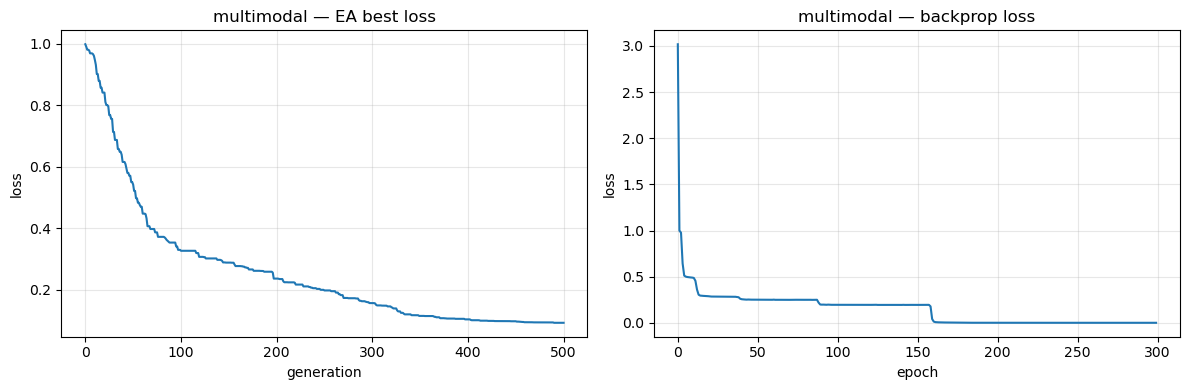

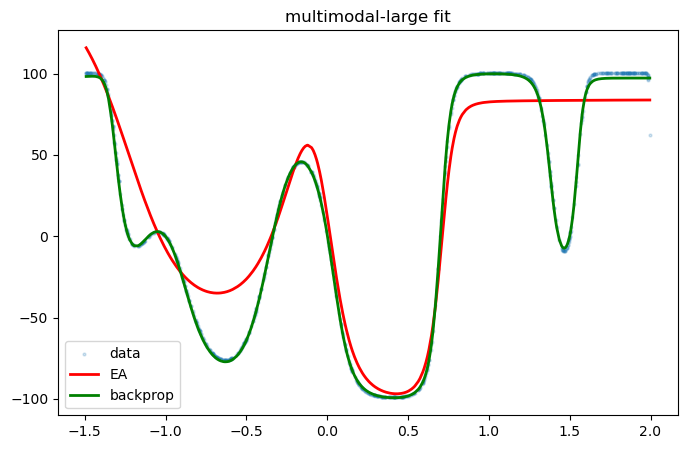

In [ ]:
Xm, ym = load_multimodal("mio1/regression/multimodal-large-training.csv")
Xmt, ymt = load_multimodal("mio1/regression/multimodal-large-test.csv")
sx = Standardizer().fit(Xm); sy = Standardizer().fit(ym)
Xm_s, Xmt_s = sx.transform(Xm), sx.transform(Xmt)
ym_s = sy.transform(ym)

from ActivationFunctions import Sigmoid
args = [1, [5, 10, 5], 1, Sigmoid(), Linear()]

rng = np.random.default_rng(SEED)
net_ea = MyNeuralNetwork(*args, RANDOM_SEED=SEED); net_ea.initialize_weights('he')
t = time.time()
trm = EvolutionaryNNTrainer(net_ea, Xm_s, ym_s, task="regression", crossover="one_point",
                            population_size=100, generations=500, sigma=0.5,
                            sigma_decay=0.997, init_std=0.4, seed=SEED)

trm.run(); ea_time = time.time() - t
ea_pred = sy.inverse(net_ea.forward(Xmt_s)); ea_rmse = rmse(ymt, ea_pred)

net_bp = MyNeuralNetwork(*args, RANDOM_SEED=SEED)
t = time.time()
bp_hist = backprop_train(net_bp, Xm_s, ym_s, epochs=300, learning_rate=0.01,
                         optimizer='adam', batch_size=64)
bp_time = time.time() - t
bp_pred = sy.inverse(net_bp.forward(Xmt_s)); bp_rmse = rmse(ymt, bp_pred)

print(f"mean-predictor RMSE = {ymt.std():.2f}")
print(f"EA  : test_rmse={ea_rmse:.3f} time={ea_time:.1f}s")
print(f"BP  : test_rmse={bp_rmse:.3f} time={bp_time:.1f}s")
plot_convergence(trm.history, bp_hist, "multimodal")

order = np.argsort(Xmt.ravel())
plt.figure(figsize=(8, 5))
plt.scatter(Xmt, ymt, s=4, alpha=.2, label="data")
plt.plot(Xmt[order], ea_pred[order], 'r', lw=2, label="EA")
plt.plot(Xmt[order], bp_pred[order], 'g', lw=2, label="backprop")
plt.legend(); plt.title("multimodal-large fit"); plt.show()
mm_row = ("multimodal/rmse", ea_rmse, bp_rmse, ea_time, bp_time)

mean-predictor RMSE = 7.77 mpg
EA  : test_rmse=10.534 mpg time=5.9s
BP  : test_rmse=6.538 mpg time=2.6s


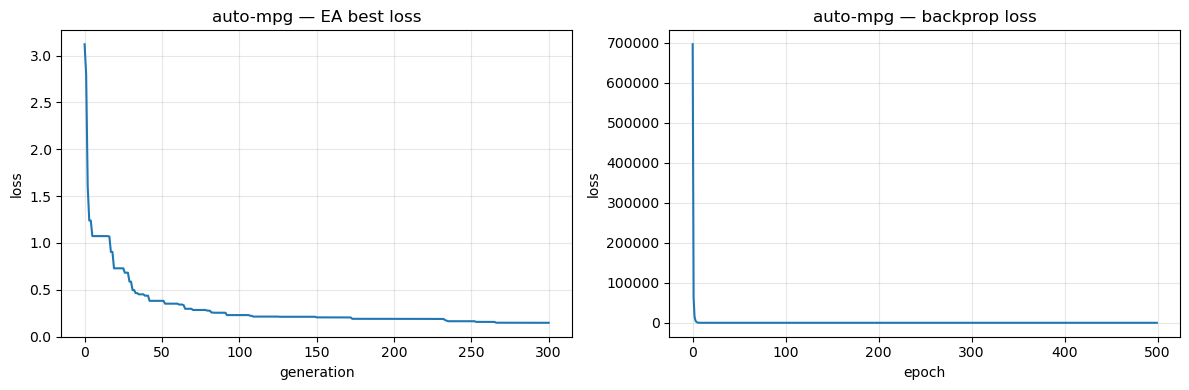

In [19]:
Xa, ya = load_auto_mpg()
Xtr, Xte, ytr, yte = train_test_split(Xa, ya, 0.3, seed=SEED)
sx = Standardizer().fit(Xtr); sy = Standardizer().fit(ytr)
Xtr_s, Xte_s = sx.transform(Xtr), sx.transform(Xte)
ytr_s = sy.transform(ytr)

args = [7, [16, 32, 16], 1, ReLU(), Linear()]

net_ea = MyNeuralNetwork(*args, RANDOM_SEED=SEED); net_ea.initialize_weights('he')
t = time.time()
tra = EvolutionaryNNTrainer(net_ea, Xtr_s, ytr_s, task="regression",
                            population_size=80, generations=300, sigma=0.15,
                            sigma_decay=0.998, init_std=0.5, seed=SEED)
tra.run(); ea_time = time.time() - t
ea_pred = sy.inverse(net_ea.forward(Xte_s)); ea_rmse = rmse(yte, ea_pred)

net_bp = MyNeuralNetwork(*args, RANDOM_SEED=SEED)
t = time.time()
bp_hist = backprop_train(net_bp, Xtr_s, ytr_s, epochs=500, learning_rate=0.01,
                         optimizer='adam', batch_size=16)
bp_time = time.time() - t
bp_pred = sy.inverse(net_bp.forward(Xte_s)); bp_rmse = rmse(yte, bp_pred)

print(f"mean-predictor RMSE = {yte.std():.2f} mpg")
print(f"EA  : test_rmse={ea_rmse:.3f} mpg time={ea_time:.1f}s")
print(f"BP  : test_rmse={bp_rmse:.3f} mpg time={bp_time:.1f}s")
plot_convergence(tra.history, bp_hist, "auto-mpg")
mpg_row = ("auto-mpg/rmse", ea_rmse, bp_rmse, ea_time, bp_time)

In [20]:
print(f"{'metric':18}{'EA':>10}{'BP':>10}{'t_EA(s)':>10}{'t_BP(s)':>10}")
for name, ea, bp, te, tb in [iris_row, mm_row, mpg_row]:
    print(f"{name:18}{ea:>10.3f}{bp:>10.3f}{te:>10.1f}{tb:>10.1f}")

metric                    EA        BP   t_EA(s)   t_BP(s)
iris/acc               0.978     0.978       2.7       0.6
multimodal/rmse       39.883     1.705     228.6      13.7
auto-mpg/rmse         10.534     6.538       5.9       2.6
